In [25]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

In [26]:
logistic = pd.read_csv("../results/logistic_regression_metrics.csv")
rf = pd.read_csv("../results/Random_Forest_metrics.csv")
xgb = pd.read_csv("../results/XGBoost_metrics.csv")
mlp = pd.read_csv("../results/MLP_metrics.csv")

comparison = pd.concat(
    [logistic, rf, xgb, mlp],
    ignore_index=True
)

comparison.to_csv("../results/Comparison_metrics.csv", index=False)

comparison.style \
    .format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-score": "{:.4f}",
        "ROC-AUC": "{:.4f}",
        "Temps (s)": "{:.4f}"
    }) \
    .highlight_max(
        subset=["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC", "Temps (s)"],
        color="lightgreen"
    )
comparison = comparison.round(4)
comparison

,Modèle,Accuracy,Precision,Recall,F1-score,ROC-AUC,Temps (s)
0,Logistic Regression,0.6106,0.0622,0.4990,0.1106,0.5576,3.0078
1,Random Forest,0.9515,0.0000,0.0000,0.0000,0.5000,1.7677
2,XGBoost,0.8461,0.0579,0.1423,0.0823,0.5121,1.0441
3,MLP(Pytorch),0.5940,0.0643,0.5443,0.1151,0.5704,64.3902


C:\Users\tapon\AppData\Local\Temp\ipykernel_112388\3696147138.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="Modèle", y=metric, palette="viridis", ax=ax)
C:\Users\tapon\AppData\Local\Temp\ipykernel_112388\3696147138.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="Modèle", y=metric, palette="viridis", ax=ax)
C:\Users\tapon\AppData\Local\Temp\ipykernel_112388\3696147138.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="Modèle", y=metric, palette="viridis", ax=ax)
C:\Users\t

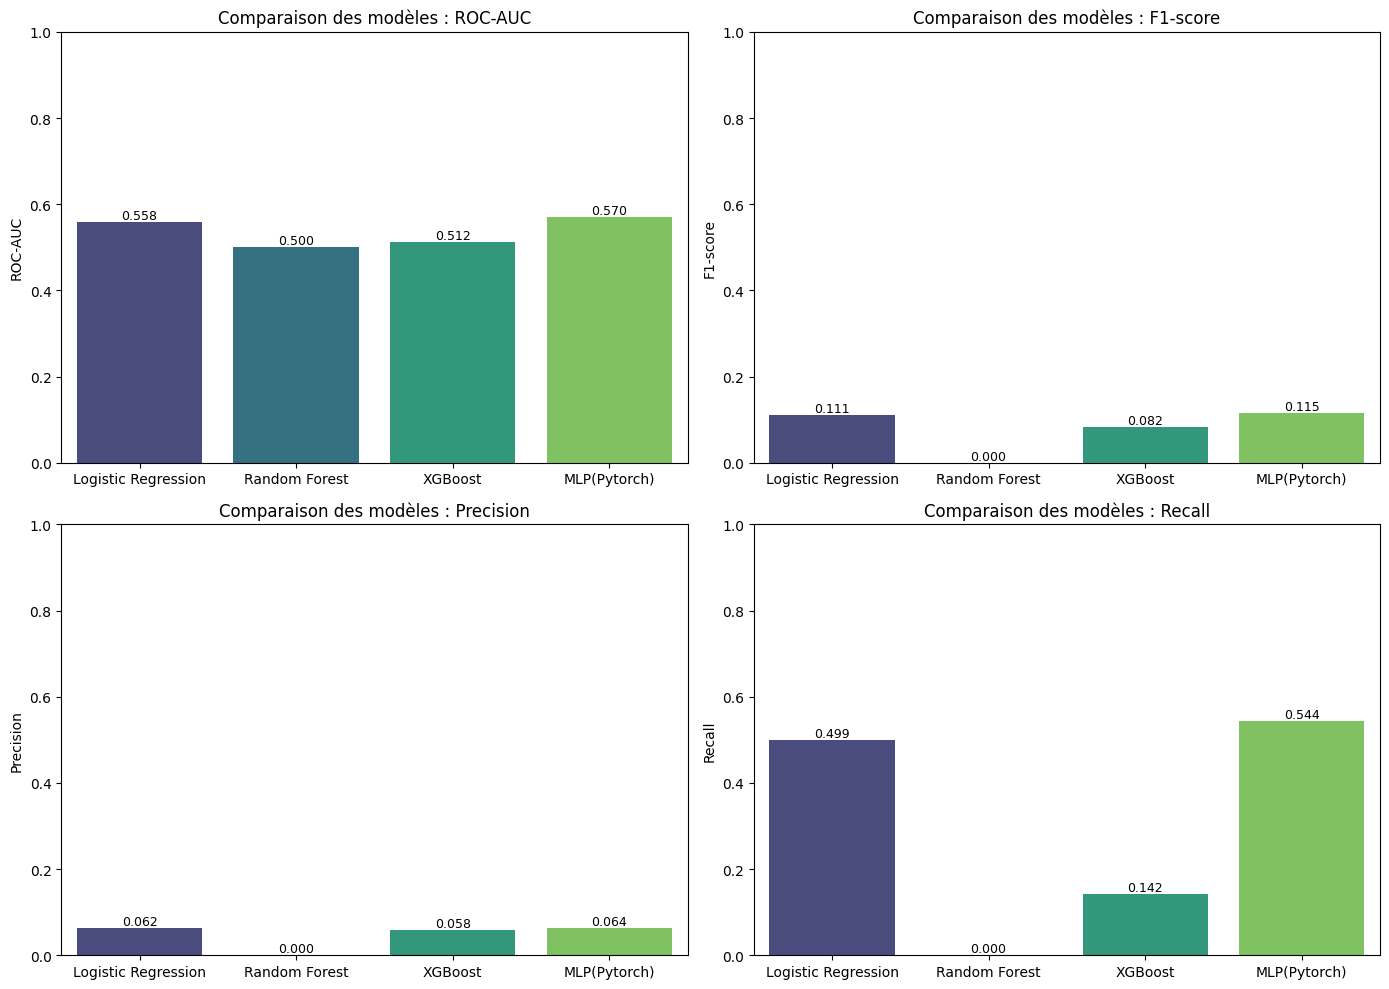

In [27]:

# Tracer les courbes de comparaison des principales métriques.
metrics = ["ROC-AUC", "F1-score", "Precision", "Recall"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharey=False)
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    sns.barplot(data=comparison, x="Modèle", y=metric, palette="viridis", ax=ax)
    ax.set_title(f"Comparaison des modèles : {metric}")
    ax.set_xlabel("")
    ax.set_ylim(0, 1)
    for patch in ax.patches:
        height = patch.get_height()
        ax.annotate(
            f"{height:.3f}",
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.tight_layout()
plt.show()


Les cellules suivantes complètent le notebook avec :

1. Graphiques en barres (Accuracy, Precision, Recall, F1-score, ROC-AUC)
2. Courbes ROC des 4 modèles
3. Matrices de confusion
4. Conclusion automatique



C:\Users\tapon\AppData\Local\Temp\ipykernel_112388\3459370955.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="Modèle", y=metric, palette="viridis", ax=ax)
C:\Users\tapon\AppData\Local\Temp\ipykernel_112388\3459370955.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="Modèle", y=metric, palette="viridis", ax=ax)
C:\Users\tapon\AppData\Local\Temp\ipykernel_112388\3459370955.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison, x="Modèle", y=metric, palette="viridis", ax=ax)
C:\Users\t

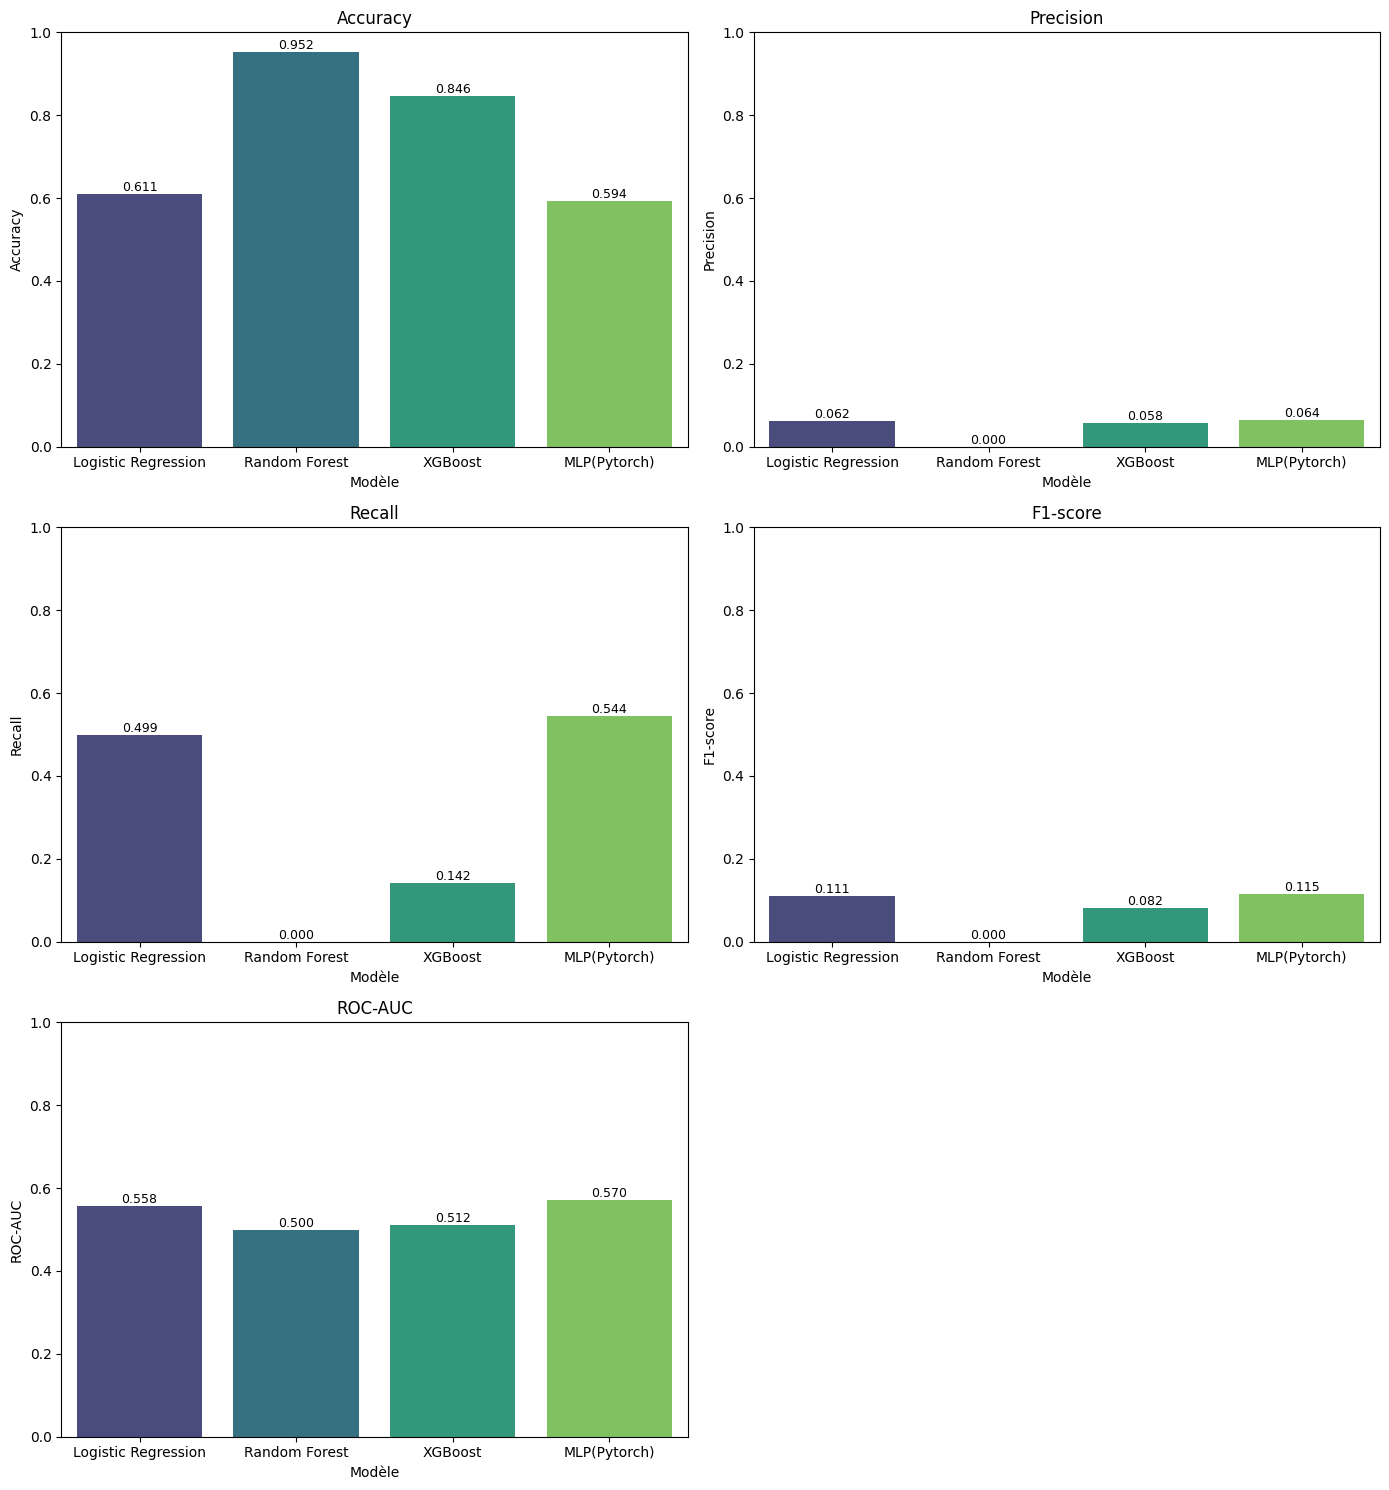

In [28]:
metrics = ["Accuracy","Precision","Recall","F1-score","ROC-AUC"]

fig, axes = plt.subplots(3,2, figsize=(14,15))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    sns.barplot(data=comparison, x="Modèle", y=metric, palette="viridis", ax=ax)
    ax.set_title(metric)
    ax.set_ylim(0,1)
    for p in ax.patches:
        ax.annotate(f"{p.get_height():.3f}",
                    (p.get_x()+p.get_width()/2, p.get_height()),
                    ha="center", va="bottom", fontsize=9)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()


../results/logistic_roc.csv introuvable.


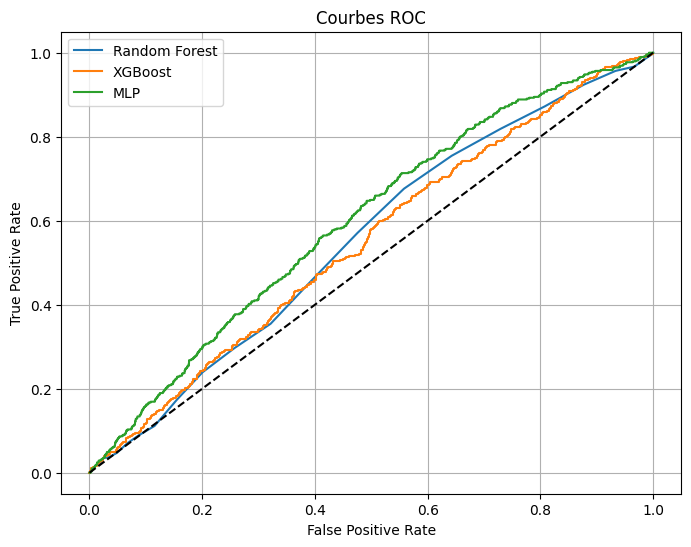

In [29]:
# Courbes ROC (nécessite les fichiers *_roc.csv)
roc_files = {
    "Logistic Regression":"../results/logistic_roc.csv",
    "Random Forest":"../results/rf_roc.csv",
    "XGBoost":"../results/xgb_roc.csv",
    "MLP":"../results/mlp_roc.csv"
}

plt.figure(figsize=(8,6))

for name, file in roc_files.items():
    try:
        roc_df = pd.read_csv(file)
        cols = {c.lower(): c for c in roc_df.columns}
        if "fpr" in cols and "tpr" in cols:
            plt.plot(roc_df[cols["fpr"]], roc_df[cols["tpr"]], label=name)
        else:
            print(f"{file} : colonnes 'fpr'/'tpr' introuvables. Colonnes disponibles: {list(roc_df.columns)}")
    except FileNotFoundError:
        print(f"{file} introuvable.")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbes ROC")
plt.legend()
plt.grid(True)
plt.show()


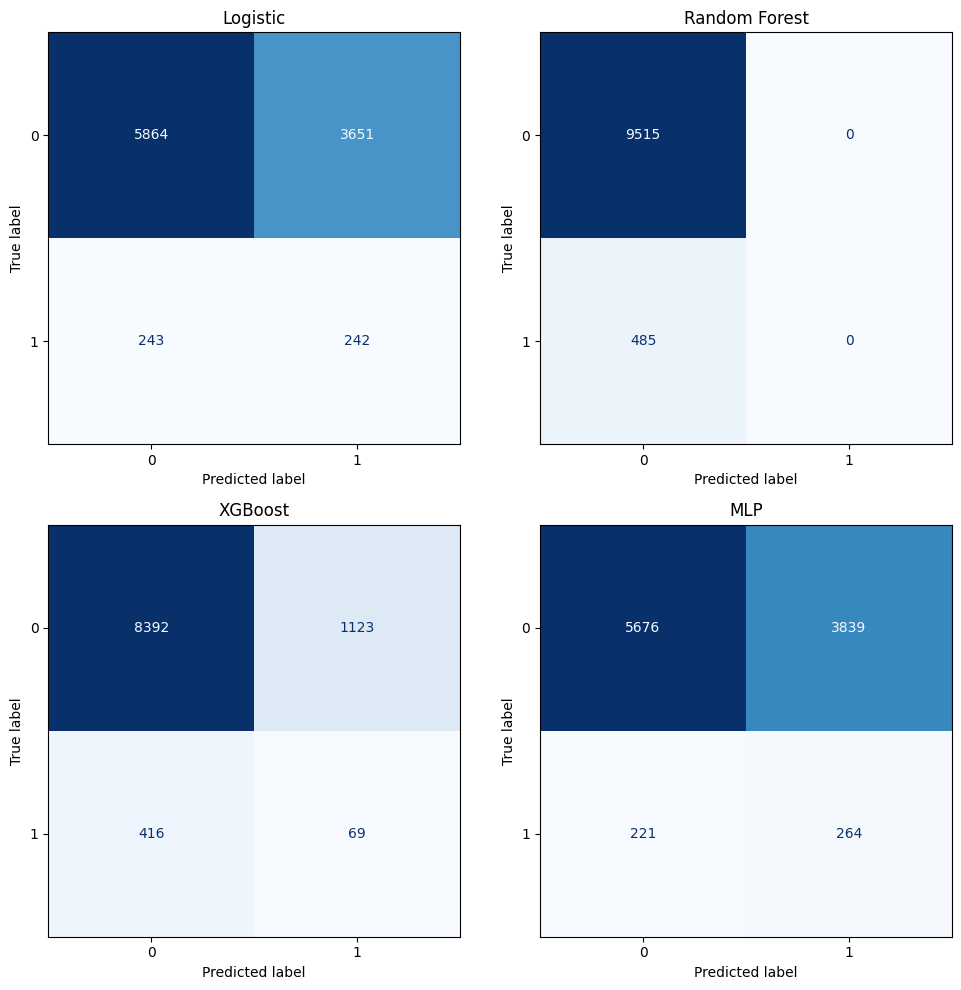

In [31]:
# Matrices de confusion des modèles enregistrées en CSV
cm_files = {
    "Logistic": "../results/lr_cm.csv",
    "Random Forest": "../results/rf_cm.csv",
    "XGBoost": "../results/xgb_cm.csv",
    "MLP": "../results/mlp_cm.csv"
}

fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, (name, file) in zip(axes.flatten(), cm_files.items()):
    try:
        cm_df = pd.read_csv(file, header=None)
        cm = cm_df.apply(pd.to_numeric, errors="coerce").astype(int).values
        if cm.size == 0 or np.isnan(cm).any():
            raise ValueError("Les données de la matrice de confusion ne sont pas toutes numériques.")
        ConfusionMatrixDisplay(cm).plot(ax=ax, cmap="Blues", colorbar=False)
        ax.set_title(name)
    except FileNotFoundError:
        ax.set_title(name)
        ax.text(0.5, 0.5, "Fichier non trouvé", ha="center")
    except Exception as exc:
        ax.set_title(name)
        ax.text(0.5, 0.5, f"Erreur: {exc}", ha="center")

plt.tight_layout()
plt.show()


In [32]:
best_auc = comparison.loc[comparison["ROC-AUC"].idxmax()]
best_recall = comparison.loc[comparison["Recall"].idxmax()]
best_f1 = comparison.loc[comparison["F1-score"].idxmax()]

print("="*70)
print("CONCLUSION AUTOMATIQUE")
print("="*70)
print(f"Meilleur ROC-AUC  : {best_auc['Modèle']} ({best_auc['ROC-AUC']:.4f})")
print(f"Meilleur Recall   : {best_recall['Modèle']} ({best_recall['Recall']:.4f})")
print(f"Meilleur F1-score : {best_f1['Modèle']} ({best_f1['F1-score']:.4f})")

print("\nINTERPRÉTATION")
print(f"""Le modèle ayant le meilleur ROC-AUC est {best_auc['Modèle']}.
Le meilleur Recall est obtenu par {best_recall['Modèle']}.
Le meilleur compromis F1-score est obtenu par {best_f1['Modèle']}.""")


CONCLUSION AUTOMATIQUE
Meilleur ROC-AUC  : MLP(Pytorch) (0.5704)
Meilleur Recall   : MLP(Pytorch) (0.5443)
Meilleur F1-score : MLP(Pytorch) (0.1151)

INTERPRÉTATION
Le modèle ayant le meilleur ROC-AUC est MLP(Pytorch).
Le meilleur Recall est obtenu par MLP(Pytorch).
Le meilleur compromis F1-score est obtenu par MLP(Pytorch).
